In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings

from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from IPython.display import display

warnings.filterwarnings("ignore")

## 1. Data Loading

In [3]:
df_customer = pd.read_csv('/content/drive/MyDrive/RFM_Clustering Project 260517/Customer_info.csv')
df_discount  = pd.read_csv('/content/drive/MyDrive/RFM_Clustering Project 260517/Discount_info.csv')
df_marketing = pd.read_csv('/content/drive/MyDrive/RFM_Clustering Project 260517/Marketing_info.csv')
df_online    = pd.read_csv('/content/drive/MyDrive/RFM_Clustering Project 260517/Onlinesales_info.csv')
df_tax       = pd.read_csv('/content/drive/MyDrive/RFM_Clustering Project 260517/Tax_info.csv')

In [4]:
df_customer.rename(columns={
    '고객ID': 'customer_id', '성별': 'gender',
    '고객지역': 'region',    '가입기간': 'tenure_months'
}, inplace=True)

df_discount.rename(columns={
    '월': 'month',          '제품카테고리': 'category',
    '쿠폰코드': 'coupon_code', '할인율': 'discount_rate'
}, inplace=True)

df_marketing.rename(columns={
    '날짜': 'date', '오프라인비용': 'offline_cost', '온라인비용': 'online_cost'
}, inplace=True)

df_online.rename(columns={
    '고객ID': 'customer_id',   '거래ID': 'transaction_id',
    '거래날짜': 'transaction_date', '제품ID': 'product_id',
    '제품카테고리': 'category', '수량': 'quantity',
    '평균금액': 'unit_price',   '배송료': 'shipping_fee',
    '쿠폰상태': 'coupon_status'
}, inplace=True)

df_tax.rename(columns={'제품카테고리': 'category', 'GST': 'gst_rate'}, inplace=True)

## 2. Data Quality Check

In [5]:
dataframes = {
    'customer': df_customer, 'discount': df_discount,
    'marketing': df_marketing, 'online': df_online, 'tax': df_tax
}

for name, df in dataframes.items():
    print(f"[{name}]  {df.shape}  |  columns: {list(df.columns)}")

[customer]  (1468, 4)  |  columns: ['customer_id', 'gender', 'region', 'tenure_months']
[discount]  (204, 4)  |  columns: ['month', 'category', 'coupon_code', 'discount_rate']
[marketing]  (365, 3)  |  columns: ['date', 'offline_cost', 'online_cost']
[online]  (52924, 9)  |  columns: ['customer_id', 'transaction_id', 'transaction_date', 'product_id', 'category', 'quantity', 'unit_price', 'shipping_fee', 'coupon_status']
[tax]  (20, 2)  |  columns: ['category', 'gst_rate']


In [6]:
# missing values
for name, df in dataframes.items():
    n = df.isnull().sum().sum()
    print(f"[{name}] missing: {n}")

print()

# duplicate rows
for name, df in dataframes.items():
    print(f"[{name}] duplicates: {df.duplicated().sum()}")

print()
print(f"transaction_id unique: {df_online['transaction_id'].nunique()} / total rows: {len(df_online)}")

[customer] missing: 0
[discount] missing: 0
[marketing] missing: 0
[online] missing: 0
[tax] missing: 0

[customer] duplicates: 0
[discount] duplicates: 0
[marketing] duplicates: 0
[online] duplicates: 0
[tax] duplicates: 0

transaction_id unique: 25061 / total rows: 52924


In [7]:
df_online['transaction_date'] = pd.to_datetime(df_online['transaction_date'])
df_marketing['date']           = pd.to_datetime(df_marketing['date'])

print(f"online    : {df_online['transaction_date'].min().date()} ~ {df_online['transaction_date'].max().date()}")
print(f"marketing : {df_marketing['date'].min().date()} ~ {df_marketing['date'].max().date()}")

online    : 2019-01-01 ~ 2019-12-31
marketing : 2019-01-01 ~ 2019-12-31


In [8]:
online_ids = set(df_online['customer_id'].unique())
profile_ids = set(df_customer['customer_id'].unique())

print(f"online customers   : {len(online_ids)}")
print(f"profile customers  : {len(profile_ids)}")
print(f"matched            : {len(online_ids & profile_ids)}")
print(f"online only        : {len(online_ids - profile_ids)}")
print(f"profile only       : {len(profile_ids - online_ids)}")

online customers   : 1468
profile customers  : 1468
matched            : 1468
online only        : 0
profile only       : 0


## 3. Outlier Investigation

Before computing any customer-level metrics, it's worth checking whether extreme transactions are data errors or genuine bulk buyers. The distinction matters — removing legitimate bulk purchases would distort the RFM calculation.

In [9]:
df_online['total_amount'] = df_online['quantity'] * df_online['unit_price']

display(df_online[['quantity', 'unit_price', 'total_amount', 'shipping_fee']].describe().round(2))

,quantity,unit_price,total_amount,shipping_fee
count,52924.0,52924.00,52924.00,52924.00
mean,4.5,52.24,88.25,10.52
std,20.1,64.01,163.99,19.48
min,1.0,0.39,0.40,0.00
25%,1.0,5.70,11.96,6.00
50%,1.0,16.99,30.39,6.00
75%,2.0,102.13,121.30,6.50
max,900.0,355.74,10512.39,521.36


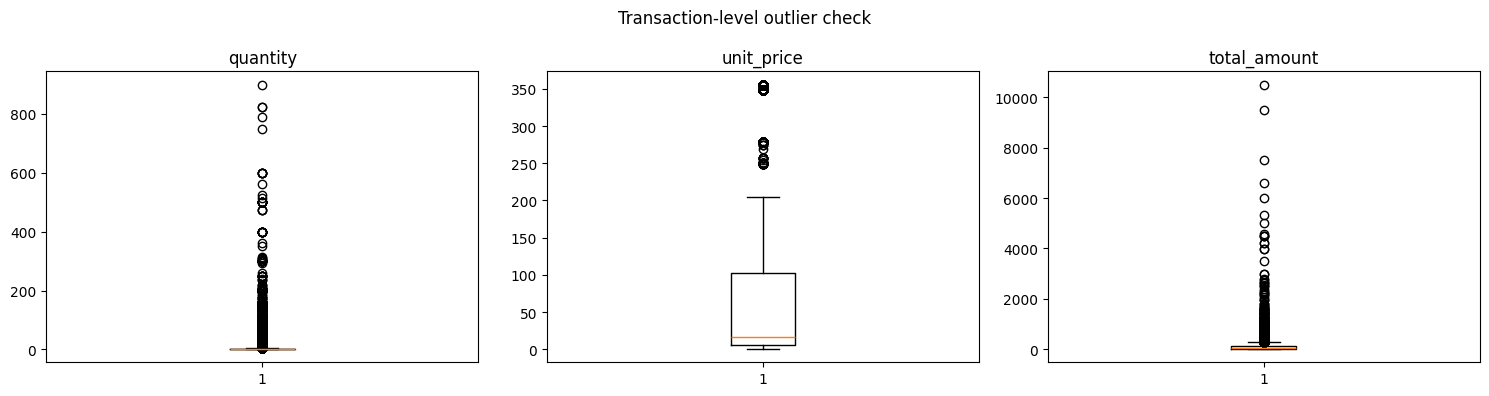

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['quantity', 'unit_price', 'total_amount']):
    ax.boxplot(df_online[col])
    ax.set_title(col)
plt.suptitle('Transaction-level outlier check', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# top transactions by quantity to see who's buying in bulk
display(df_online.nlargest(10, 'quantity')[
    ['customer_id', 'transaction_date', 'category', 'quantity', 'unit_price', 'total_amount']
])

,customer_id,transaction_date,category,quantity,unit_price,total_amount
42456,USER_0546,2019-10-16,Office,900,0.99,891.00
20992,USER_1081,2019-06-05,Office,825,0.79,651.75
21364,USER_1361,2019-06-08,Office,825,0.79,651.75
30192,USER_0703,2019-08-02,Headgear,791,13.29,10512.39
12173,USER_0214,2019-04-05,Lifestyle,750,3.50,2625.00
5544,USER_0746,2019-02-14,Bags,600,4.99,2994.00
12176,USER_0214,2019-04-05,Office,600,10.99,6594.00
30795,USER_0806,2019-08-04,Office,600,2.39,1434.00
33422,USER_1229,2019-08-18,Office,600,0.79,474.00
42941,USER_0686,2019-10-20,Office,600,0.99,594.00


In [12]:
# check 99th percentile thresholds and how many customers are affected
q99 = {col: df_online[col].quantile(0.99) for col in ['quantity', 'unit_price', 'total_amount']}
print("99th percentile:", {k: round(v, 2) for k, v in q99.items()})

outlier_mask = (
    (df_online['quantity']     > q99['quantity'])    |
    (df_online['unit_price']   > q99['unit_price'])  |
    (df_online['total_amount'] > q99['total_amount'])
)
print(f"\nflagged transactions : {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)")
print(f"customers involved   : {df_online[outlier_mask]['customer_id'].nunique()}")
print()

# 553 out of 1468 customers have at least one transaction flagged.
# These aren't errors — multiple distinct customers show the same bulk-buying pattern,
# particularly in the Office category (low unit price, very high quantity).
# Removing them at transaction level would over-penalize otherwise normal customers
# who made one large purchase. Instead, we handle skew at the customer level
# using winsorization and log transformation during feature engineering.

99th percentile: {'quantity': np.float64(60.0), 'unit_price': np.float64(279.0), 'total_amount': np.float64(557.72)}

flagged transactions : 1345 (2.5%)
customers involved   : 553



## 4. EDA

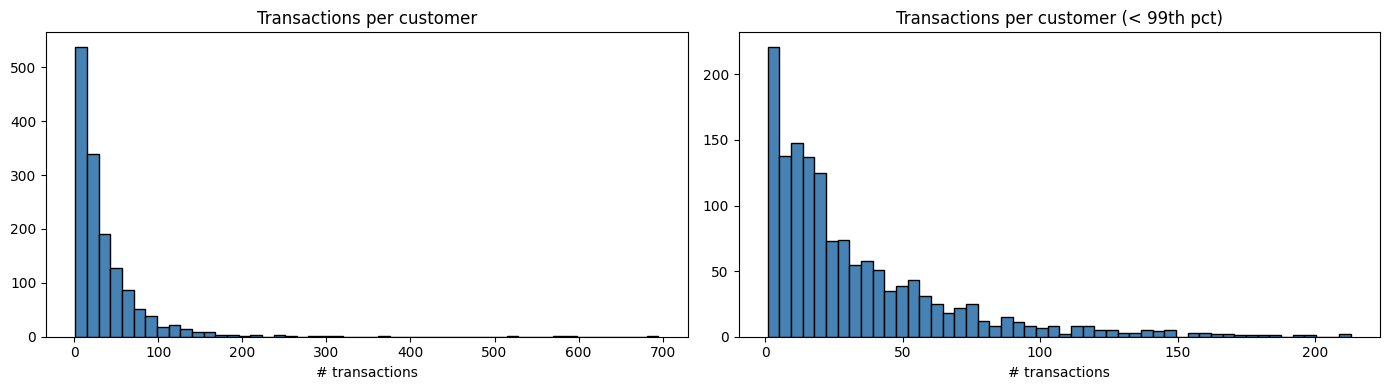

count    1468.0
mean       36.1
std        50.9
min         1.0
25%        10.0
50%        21.0
75%        46.0
max       695.0
Name: transaction_id, dtype: float64

single-transaction customers : 66 (4.5%)


In [13]:
# transaction frequency per customer
txn_per_customer = df_online.groupby('customer_id')['transaction_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(txn_per_customer, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Transactions per customer')
axes[0].set_xlabel('# transactions')

cap = txn_per_customer.quantile(0.99)
axes[1].hist(txn_per_customer[txn_per_customer <= cap], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Transactions per customer (< 99th pct)')
axes[1].set_xlabel('# transactions')

plt.tight_layout()
plt.show()

print(txn_per_customer.describe().round(1))
print(f"\nsingle-transaction customers : {(txn_per_customer == 1).sum()} ({(txn_per_customer == 1).mean()*100:.1f}%)")

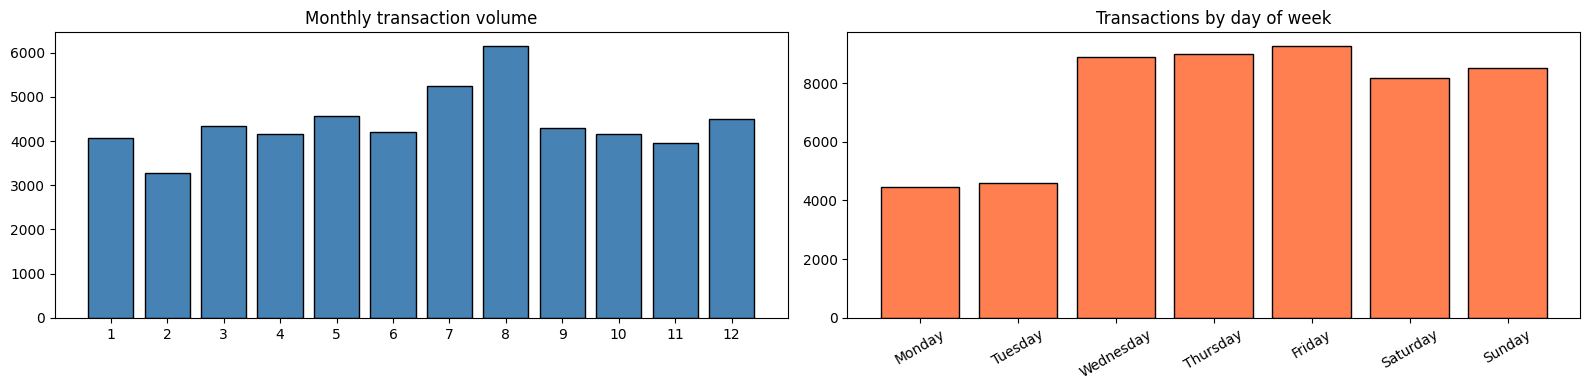

In [14]:
df_online['month']     = df_online['transaction_date'].dt.month
df_online['dayofweek'] = df_online['transaction_date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

monthly = df_online.groupby('month')['transaction_id'].count()
axes[0].bar(monthly.index, monthly.values, color='steelblue', edgecolor='black')
axes[0].set_title('Monthly transaction volume')
axes[0].set_xticks(range(1, 13))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df_online.groupby('dayofweek')['transaction_id'].count().reindex(dow_order)
axes[1].bar(dow.index, dow.values, color='coral', edgecolor='black')
axes[1].set_title('Transactions by day of week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

,txn_count,total_revenue,unique_customers,avg_unit_price,rev_pct
category,,,,,
Nest-USA,14013,2554202.39,1260,124.33,54.7
Apparel,18126,591145.80,1323,19.79,12.7
Nest,2198,518193.50,516,194.22,11.1
Office,6513,276794.40,1103,3.77,5.9
Drinkware,3483,200707.83,919,10.70,4.3
Bags,1882,151314.43,728,29.83,3.2
Notebooks & Journals,749,107085.96,383,11.76,2.3
Lifestyle,3092,74385.70,817,3.86,1.6
Nest-Canada,317,70910.40,205,157.24,1.5


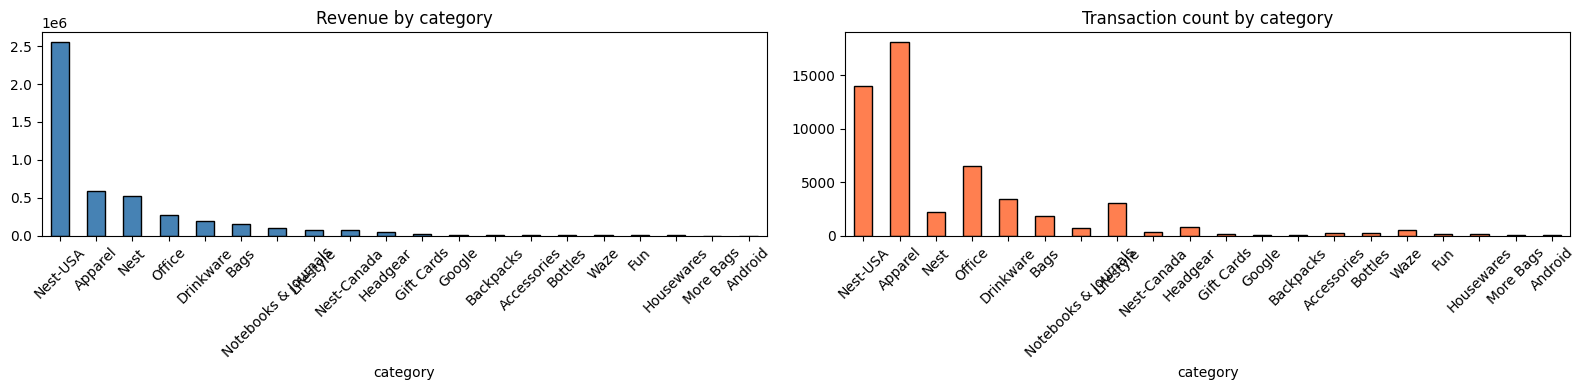

In [15]:
cat_stats = df_online.groupby('category').agg(
    txn_count        = ('transaction_id', 'count'),
    total_revenue    = ('total_amount', 'sum'),
    unique_customers = ('customer_id', 'nunique'),
    avg_unit_price   = ('unit_price', 'mean')
).sort_values('total_revenue', ascending=False).round(2)

cat_stats['rev_pct'] = (cat_stats['total_revenue'] / cat_stats['total_revenue'].sum() * 100).round(1)
display(cat_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
cat_stats['total_revenue'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Revenue by category')
axes[0].tick_params(axis='x', rotation=45)

cat_stats['txn_count'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Transaction count by category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
coupon_dist = df_online['coupon_status'].value_counts()
print(coupon_dist)
print(f"\ncoupon usage rate: {coupon_dist.get('Used', 0) / len(df_online) * 100:.1f}%")
print()

# notably, average transaction amount barely differs across coupon status
print(df_online.groupby('coupon_status')['total_amount'].mean().round(2))

coupon_status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64

coupon usage rate: 33.8%

coupon_status
Clicked     88.29
Not Used    90.53
Used        87.18
Name: total_amount, dtype: float64


In [17]:
df_merged = df_online.merge(df_customer, on='customer_id', how='left')

gender_stats = df_merged.groupby('gender').agg(
    n_customers   = ('customer_id', 'nunique'),
    txn_count     = ('transaction_id', 'count'),
    total_revenue = ('total_amount', 'sum'),
    avg_txn       = ('total_amount', 'mean')
).round(2)
display(gender_stats)

# Female total revenue is higher, but avg transaction amount is nearly identical.
# The gap comes entirely from customer count (934 female vs 534 male),
# not from different spending behavior.
print()

region_stats = df_merged.groupby('region').agg(
    n_customers   = ('customer_id', 'nunique'),
    total_revenue = ('total_amount', 'sum'),
    avg_txn       = ('total_amount', 'mean')
).sort_values('total_revenue', ascending=False).head(10).round(2)
display(region_stats)

,n_customers,txn_count,total_revenue,avg_txn
gender,,,,
남,534,19917,1767124.39,88.72
여,934,33007,2903670.23,87.97


,n_customers,total_revenue,avg_txn
region,,,
Chicago,456,1625885.58,88.46
California,464,1442447.31,89.39
New York,324,937022.63,83.86
New Jersey,149,409666.86,90.98
Washington DC,75,255772.24,93.62


## 5. RFM Feature Engineering

**Frequency** is defined as the number of distinct purchase dates rather than raw transaction count. Many customers place multiple orders on the same day (bulk buying or browsing sessions), so counting unique dates gives a cleaner signal of actual return visit behavior.

**Monetary** is the sum of `quantity × unit_price` across all transactions per customer.

In [18]:
reference_date = df_online['transaction_date'].max() + datetime.timedelta(days=1)
print(f"reference date: {reference_date.date()}")

rfm = df_online.groupby('customer_id').agg(
    recency   = ('transaction_date', lambda x: (reference_date - x.max()).days),
    frequency = ('transaction_date', lambda x: x.dt.date.nunique()),
    monetary  = ('total_amount', 'sum')
).reset_index()

display(rfm.describe().round(2))

reference date: 2020-01-01


,recency,frequency,monetary
count,1468.00,1468.00,1468.00
mean,145.29,2.19,3181.74
std,101.94,2.24,5065.80
min,1.00,1.00,1.00
25%,56.00,1.00,652.41
50%,132.00,1.50,1750.41
75%,221.00,3.00,3917.89
max,365.00,34.00,75937.55


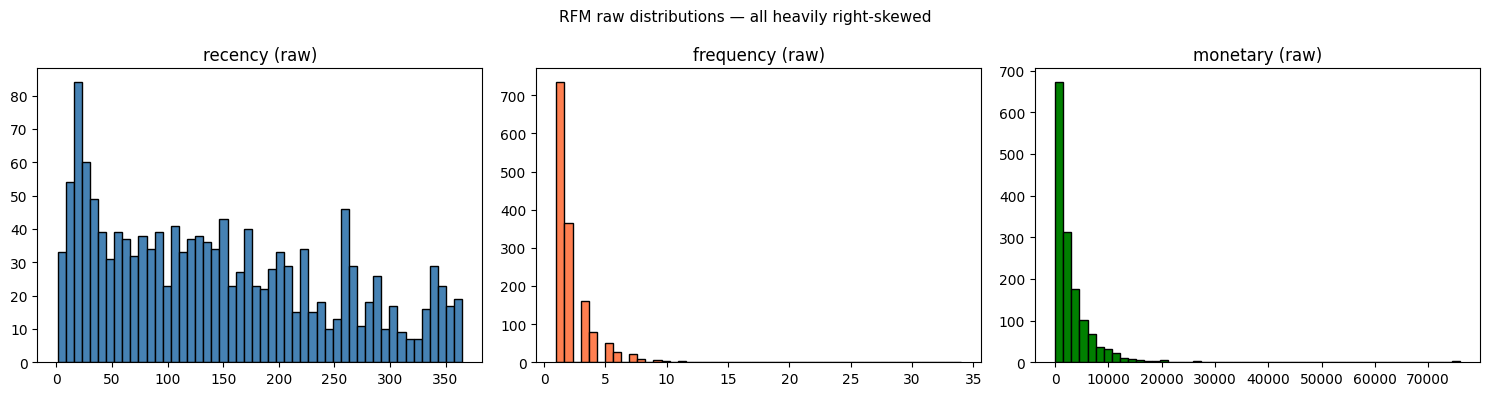

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, c in zip(axes, ['recency', 'frequency', 'monetary'], ['steelblue', 'coral', 'green']):
    ax.hist(rfm[col], bins=50, color=c, edgecolor='black')
    ax.set_title(f'{col} (raw)')
plt.suptitle('RFM raw distributions — all heavily right-skewed', fontsize=11)
plt.tight_layout()
plt.show()

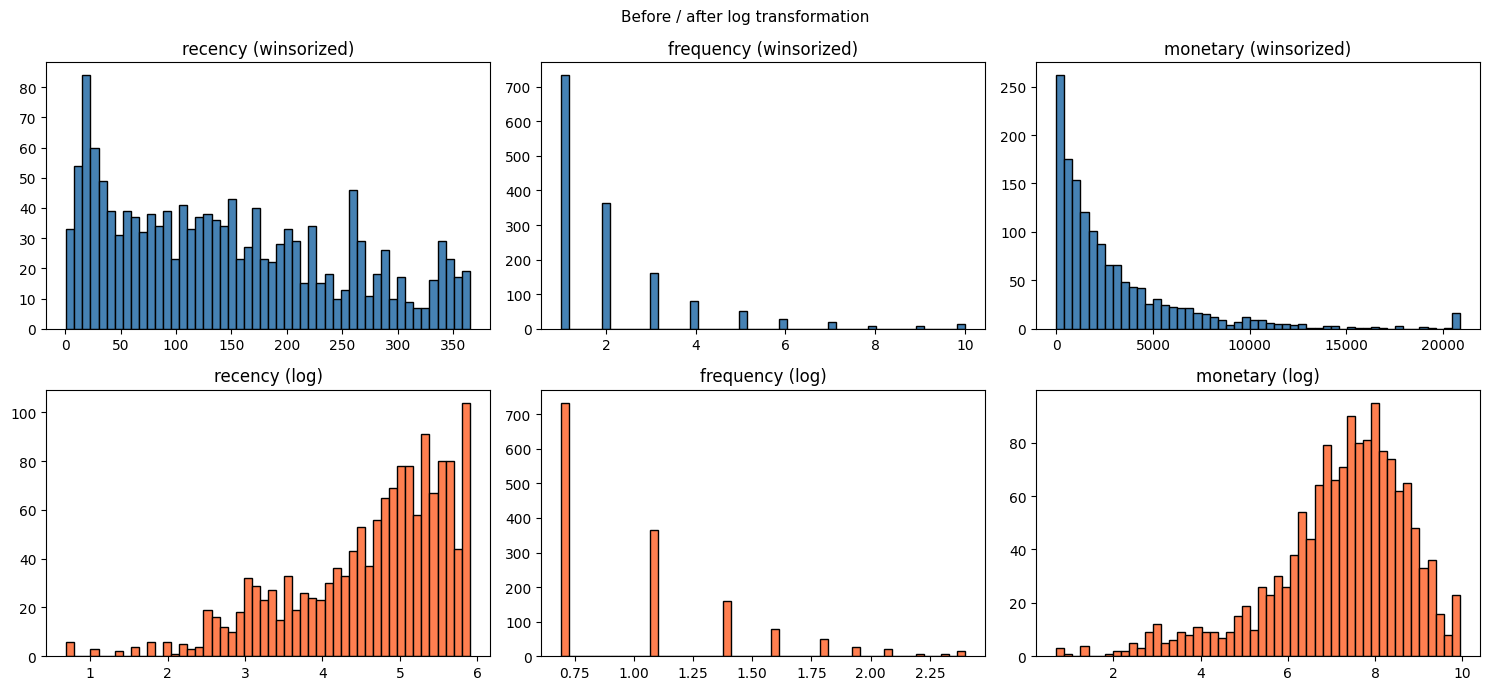

,log_recency,log_frequency,log_monetary
count,1468.0000,1468.0000,1468.0000
mean,4.6141,1.0342,7.2046
std,1.0148,0.4197,1.5704
min,0.6931,0.6931,0.6931
25%,4.0431,0.6931,6.4822
50%,4.8903,0.8959,7.4682
75%,5.4027,1.3863,8.2736
max,5.9026,2.3979,9.9456


In [20]:
# Frequency and Monetary are winsorized at 99th percentile before log transformation
# to prevent a handful of extreme buyers from dominating the cluster geometry.
# Recency is left as-is since its range (1-365 days) is already bounded.

rfm_transformed = rfm.copy()
rfm_transformed['monetary']  = winsorize(rfm['monetary'],  limits=[0, 0.01])
rfm_transformed['frequency'] = winsorize(rfm['frequency'], limits=[0, 0.01])

rfm_transformed['log_recency']   = np.log1p(rfm_transformed['recency'])
rfm_transformed['log_frequency'] = np.log1p(rfm_transformed['frequency'])
rfm_transformed['log_monetary']  = np.log1p(rfm_transformed['monetary'])

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (raw, log) in enumerate(zip(['recency','frequency','monetary'],
                                    ['log_recency','log_frequency','log_monetary'])):
    axes[0,i].hist(rfm_transformed[raw], bins=50, color='steelblue', edgecolor='black')
    axes[0,i].set_title(f'{raw} (winsorized)')
    axes[1,i].hist(rfm_transformed[log], bins=50, color='coral', edgecolor='black')
    axes[1,i].set_title(f'{raw} (log)')
plt.suptitle('Before / after log transformation', fontsize=11)
plt.tight_layout()
plt.show()

display(rfm_transformed[['log_recency','log_frequency','log_monetary']].describe().round(4))

## 6. Additional Features

Beyond R, F, M, a few behavioral signals can help separate customers who look similar on spending alone:

- **avg_order_value** — spend per transaction (different from total monetary)
- **category_diversity** — breadth of categories explored
- **coupon_use_rate** — proportion of transactions where a coupon was applied
- **avg_interpurchase_days** — mean gap between consecutive purchase dates
- **is_single_day_buyer** — binary flag for customers with only one purchase date (no interval to compute)

In [21]:
rfm_extra = df_online.groupby('customer_id').agg(
    avg_order_value    = ('total_amount', 'mean'),
    category_diversity = ('category', 'nunique'),
    coupon_use_rate    = ('coupon_status', lambda x: (x == 'Used').sum() / len(x)),
    total_quantity     = ('quantity', 'sum'),
    active_span_days   = ('transaction_date', lambda x: (x.max() - x.min()).days)
).reset_index()

def avg_interpurchase(dates):
    days = sorted(dates.dt.date.unique())
    if len(days) < 2:
        return np.nan
    return np.mean([(days[i+1] - days[i]).days for i in range(len(days)-1)])

interpurchase = (
    df_online.groupby('customer_id')['transaction_date']
    .apply(avg_interpurchase)
    .reset_index()
    .rename(columns={'transaction_date': 'avg_interpurchase_days'})
)

rfm_full = rfm_transformed.merge(rfm_extra, on='customer_id')
rfm_full = rfm_full.merge(interpurchase, on='customer_id')
rfm_full = rfm_full.merge(df_customer, on='customer_id')

print(f"customers with only 1 purchase day: {rfm_full['avg_interpurchase_days'].isna().sum()}")

customers with only 1 purchase day: 734


In [22]:
# NaN interpurchase means the customer never returned — flag separately and fill with 0
rfm_full['is_single_day_buyer']      = rfm_full['avg_interpurchase_days'].isna().astype(int)
rfm_full['avg_interpurchase_days']   = rfm_full['avg_interpurchase_days'].fillna(0)

rfm_full['log_avg_order_value']  = np.log1p(rfm_full['avg_order_value'])
rfm_full['log_avg_interpurchase'] = np.log1p(rfm_full['avg_interpurchase_days'])

clustering_features = [
    'log_recency', 'log_frequency', 'log_monetary',
    'log_avg_order_value', 'category_diversity',
    'coupon_use_rate', 'log_avg_interpurchase', 'is_single_day_buyer'
]

df_cluster = rfm_full[['customer_id'] + clustering_features].copy()

print(f"features : {len(clustering_features)}")
print(f"customers: {len(df_cluster)}")
print(f"any NaN  : {df_cluster[clustering_features].isnull().any().any()}")

features : 8
customers: 1468
any NaN  : False


## 7. Clustering

### 7.1 Scaling

StandardScaler is applied so no single feature dominates the distance metric due to scale differences.

In [23]:
scaler   = StandardScaler()
X        = df_cluster[clustering_features].values
X_scaled = scaler.fit_transform(X)

### 7.2 Choosing K

Three metrics are used together to pick K:
- **Inertia (Elbow)** — rate of within-cluster variance reduction
- **Silhouette score** — how well-separated clusters are (higher = better)
- **Davies-Bouldin index** — ratio of within-cluster to between-cluster distance (lower = better)

K=2  inertia=7,435  silhouette=0.3524  DB=1.1926
K=3  inertia=6,165  silhouette=0.3357  DB=1.2313
K=4  inertia=5,429  silhouette=0.2601  DB=1.4575
K=5  inertia=4,909  silhouette=0.2658  DB=1.3288
K=6  inertia=4,430  silhouette=0.2436  DB=1.3530
K=7  inertia=4,132  silhouette=0.2360  DB=1.3805
K=8  inertia=3,860  silhouette=0.2166  DB=1.3901
K=9  inertia=3,622  silhouette=0.2084  DB=1.4051
K=10  inertia=3,392  silhouette=0.2193  DB=1.3394


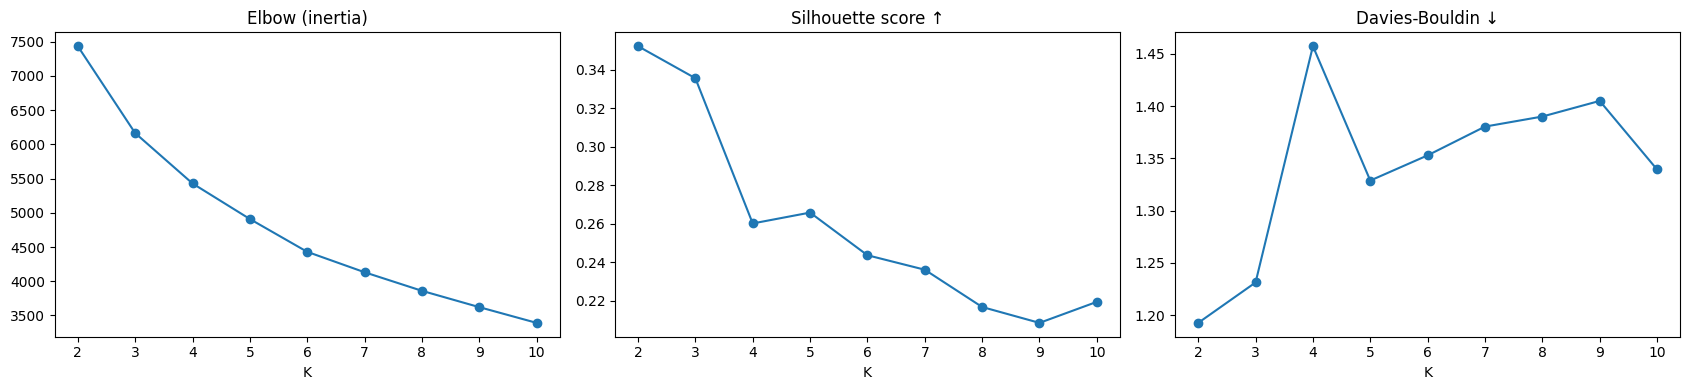

In [24]:
inertia, silhouette, db_index = [], [], []
K_range = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    db_index.append(davies_bouldin_score(X_scaled, labels))
    print(f"K={k}  inertia={km.inertia_:,.0f}  silhouette={silhouette[-1]:.4f}  DB={db_index[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, vals, title in zip(axes,
                            [inertia, silhouette, db_index],
                            ['Elbow (inertia)', 'Silhouette score ↑', 'Davies-Bouldin ↓']):
    ax.plot(K_range, vals, 'o-')
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.set_xticks(K_range)
plt.tight_layout()
plt.show()

All three metrics point to **K=3**:
- Silhouette peaks at K=2 (0.352) and drops sharply from K=4 onward
- Davies-Bouldin is lowest at K=2, second at K=3
- The elbow in inertia is at K=3

K=2 gives the cleanest separation statistically but collapses into a binary split that has limited business utility. K=3 is the next best on all three metrics and yields interpretable, actionable segments.

In [25]:
OPTIMAL_K = 3

kmeans            = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette : {silhouette_score(X_scaled, df_cluster['cluster']):.4f}")
print(f"Davies-Bouldin : {davies_bouldin_score(X_scaled, df_cluster['cluster']):.4f}")
print()
print(df_cluster['cluster'].value_counts().sort_index().rename('count'))

Silhouette : 0.3357
Davies-Bouldin : 1.2313

cluster
0    590
1    712
2    166
Name: count, dtype: int64


In [26]:
rfm_profiling           = rfm_full.copy()
rfm_profiling['cluster'] = df_cluster['cluster'].values

profile_cols = ['recency', 'frequency', 'monetary', 'avg_order_value',
                'category_diversity', 'coupon_use_rate', 'avg_interpurchase_days', 'is_single_day_buyer']

profile = rfm_profiling.groupby('cluster')[profile_cols].mean().round(2)
display(profile)

,recency,frequency,monetary,avg_order_value,category_diversity,coupon_use_rate,avg_interpurchase_days,is_single_day_buyer
cluster,,,,,,,,
0,173.40,1.01,1848.96,102.04,5.12,0.33,0.01,0.99
1,111.93,3.27,4653.65,90.11,7.72,0.34,65.50,0.00
2,188.48,1.10,106.59,21.30,2.22,0.37,6.09,0.91


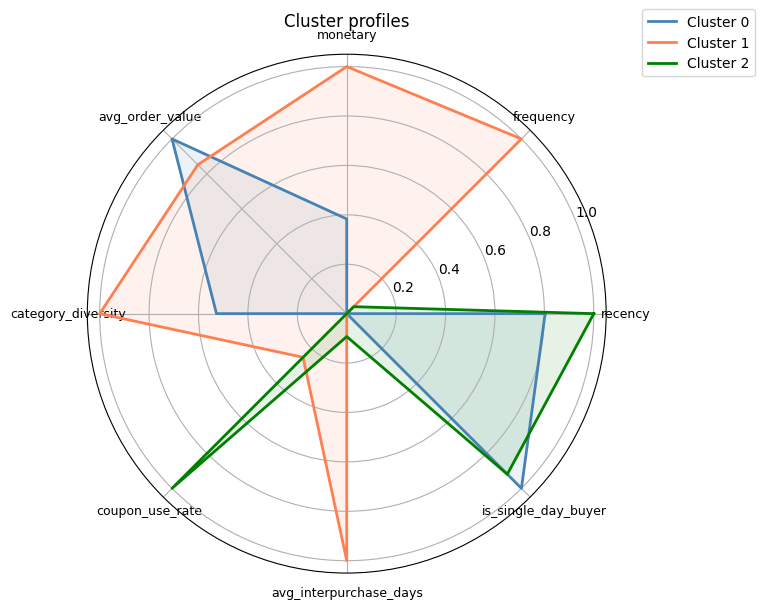

In [27]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

num_vars = len(profile_cols)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['steelblue', 'coral', 'green']

for i, (idx, row) in enumerate(profile_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, color=colors[i], linewidth=2, label=f'Cluster {idx}')
    ax.fill(angles, vals, color=colors[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_cols, size=9)
ax.set_title('Cluster profiles', size=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# Note: recency is inverted on this chart — higher value = longer since last purchase = worse.

variance explained: PC1=46.1%, PC2=17.0%, total=63.0%


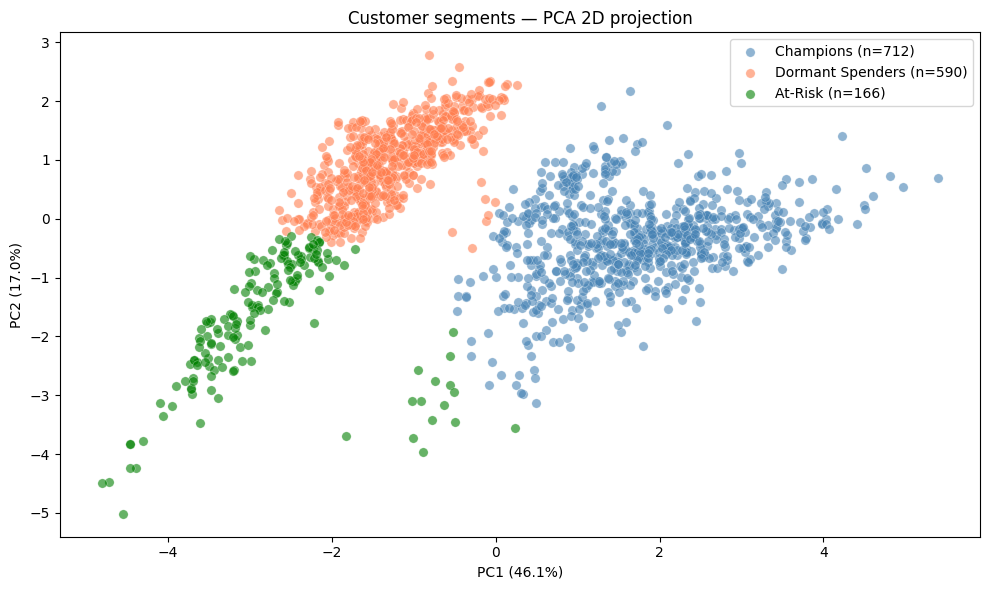

In [28]:
label_map = {1: 'Champions', 0: 'Dormant Spenders', 2: 'At-Risk'}
df_cluster['segment']    = df_cluster['cluster'].map(label_map)
rfm_profiling['segment'] = df_cluster['segment'].values

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}, total={pca.explained_variance_ratio_.sum():.1%}")

colors_map = {'Champions': 'steelblue', 'Dormant Spenders': 'coral', 'At-Risk': 'green'}
fig, ax    = plt.subplots(figsize=(10, 6))

for seg, col in colors_map.items():
    mask = df_cluster['segment'] == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=col, label=f'{seg} (n={mask.sum()})',
               alpha=0.6, edgecolors='white', linewidth=0.3, s=45)

ax.set_title('Customer segments — PCA 2D projection', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [29]:
summary = rfm_profiling.groupby('segment').agg(
    n_customers   = ('customer_id', 'count'),
    avg_recency   = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary', 'mean'),
    avg_cat_div   = ('category_diversity', 'mean'),
    total_revenue = ('monetary', 'sum')
).round(2)
summary['revenue_pct'] = (summary['total_revenue'] / summary['total_revenue'].sum() * 100).round(1)
display(summary)

,n_customers,avg_recency,avg_frequency,avg_monetary,avg_cat_div,total_revenue,revenue_pct
segment,,,,,,,
At-Risk,166,188.48,1.10,106.59,2.22,17693.57,0.4
Champions,712,111.93,3.27,4653.65,7.72,3313401.07,74.9
Dormant Spenders,590,173.40,1.01,1848.96,5.12,1090884.95,24.7


## 8. Algorithm Validation — Agglomerative Clustering

K-Means minimizes within-cluster variance, which assumes roughly spherical clusters. To check whether the cluster structure is an artifact of the algorithm rather than genuine data geometry, we run Agglomerative Clustering (Ward linkage) on the same scaled features.

In [30]:
agg        = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

print(f"Agglomerative — Silhouette: {silhouette_score(X_scaled, agg_labels):.4f}  |  DB: {davies_bouldin_score(X_scaled, agg_labels):.4f}")
print(f"K-Means       — Silhouette: {silhouette_score(X_scaled, df_cluster['cluster'].values):.4f}  |  DB: {davies_bouldin_score(X_scaled, df_cluster['cluster'].values):.4f}")

ari = adjusted_rand_score(df_cluster['cluster'].values, agg_labels)
print(f"\nAdjusted Rand Index: {ari:.4f}  (1.0 = identical, 0.0 = random)")

Agglomerative — Silhouette: 0.3441  |  DB: 1.2372
K-Means       — Silhouette: 0.3357  |  DB: 1.2313

Adjusted Rand Index: 0.8763  (1.0 = identical, 0.0 = random)


In [31]:
cross = pd.crosstab(
    pd.Series(df_cluster['cluster'].values, name='K-Means'),
    pd.Series(agg_labels, name='Agglomerative')
)
display(cross)

# ARI of 0.876 means the two algorithms independently arrive at nearly the same partitioning.
# The cluster structure is in the data, not an artifact of K-Means assumptions.

Agglomerative,0,1,2
K-Means,,,
0,7,8,575
1,711,0,1
2,15,97,54


## 9. Traditional RFM vs K-Means

Traditional RFM assigns each customer a score from 1 to 5 on Recency, Frequency and Monetary using quintile cuts, then sums the scores into segments. The boundaries are determined by the score thresholds we set, not by the data.

The comparison below shows how often the two methods agree — and where they systematically disagree.

In [32]:
rfm_scored = rfm_full[['customer_id', 'recency', 'frequency', 'monetary']].copy()

rfm_scored['R_score'] = pd.qcut(rfm_scored['recency'],  q=5, labels=[5,4,3,2,1]).astype(int)
rfm_scored['F_score'] = pd.qcut(rfm_scored['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm_scored['M_score'] = pd.qcut(rfm_scored['monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)
rfm_scored['RFM_total'] = rfm_scored['R_score'] + rfm_scored['F_score'] + rfm_scored['M_score']

def rfm_label(score):
    if score >= 12: return 'Champions'
    elif score >= 8: return 'Dormant Spenders'
    else: return 'At-Risk'

rfm_scored['rfm_segment'] = rfm_scored['RFM_total'].apply(rfm_label)
print(rfm_scored['rfm_segment'].value_counts())

rfm_segment
Dormant Spenders    573
At-Risk             534
Champions           361
Name: count, dtype: int64


In [36]:
comparison_df = rfm_scored[['customer_id','rfm_segment','R_score','F_score','M_score','RFM_total']].copy()
comparison_df['kmeans_segment'] = df_cluster['segment'].values

agreement = (comparison_df['rfm_segment'] == comparison_df['kmeans_segment']).mean()
print(f"agreement rate: {agreement:.1%}")
print()

cross = pd.crosstab(comparison_df['rfm_segment'], comparison_df['kmeans_segment'], margins=True)
display(cross)

disagreement = comparison_df[comparison_df['rfm_segment'] != comparison_df['kmeans_segment']]
print(f"\ncustomers classified differently: {len(disagreement)} ({len(disagreement)/len(comparison_df)*100:.1f}%)")

agreement rate: 49.2%



kmeans_segment,At-Risk,Champions,Dormant Spenders,All
rfm_segment,,,,
At-Risk,150,27,357,534
Champions,0,350,11,361
Dormant Spenders,16,335,222,573
All,166,712,590,1468



customers classified differently: 746 (50.8%)


In [37]:
display(disagreement.groupby(['rfm_segment','kmeans_segment']).agg(
    count=('customer_id','count'),
    avg_R=('R_score','mean'),
    avg_F=('F_score','mean'),
    avg_M=('M_score','mean')
).round(2))

count  avg_R  avg_F  avg_M
rfm_segment      kmeans_segment                              
At-Risk          Champions            27   1.70   3.41   1.70
                 Dormant Spenders    357   1.93   1.71   2.18
Champions        Dormant Spenders     11   4.91   2.82   4.82
Dormant Spenders At-Risk              16   4.25   3.00   1.00
                 Champions           335   2.71   3.90   3.15

In [38]:
# The most consequential disagreement: 335 customers that RFM scores as Dormant Spenders
# are classified as Champions by K-Means. These customers have moderate R scores
# that drag down their RFM total, but their behavioral profile (frequency, category breadth,
# return visit interval) aligns with the champion cluster.

missed = comparison_df[
    (comparison_df['rfm_segment']    == 'Dormant Spenders') &
    (comparison_df['kmeans_segment'] == 'Champions')
]['customer_id']

revenue_missed = rfm_full[rfm_full['customer_id'].isin(missed)]['monetary'].sum()
print(f"customers traditional RFM underclassified as Champions : {len(missed)}")
print(f"their combined monetary value                          : ${revenue_missed:,.0f}")

customers traditional RFM underclassified as Champions : 335
their combined monetary value                          : $879,941


## 10. Segment Profiles & Business Implications

| Segment | Customers | Revenue share | Avg recency | Avg frequency | Avg monetary |
|---|---|---|---|---|---|
| Champions | 712 (48.5%) | 74.9% | 112 days | 3.3 days | $4,654 |
| Dormant Spenders | 590 (40.2%) | 24.7% | 173 days | 1.0 days | $1,849 |
| At-Risk | 166 (11.3%) | 0.4% | 188 days | 1.1 days | $107 |

**Champions** generate nearly three-quarters of total revenue. They return regularly (~65 day intervals), buy across 7.7 categories on average, and are the primary target for retention investment.

**Dormant Spenders** are mostly single-session buyers — 99% have only one purchase date. They spent a meaningful amount in that one visit, which suggests product-market fit, but never came back. The priority is converting first-time sessions into repeat behaviour.

**At-Risk** represent 11% of customers but just 0.4% of revenue. Over-investing in win-back campaigns here is unlikely to pay off. They're more useful as a reference for what low-engagement acquisition looks like.

In [39]:
reactivation_timing = rfm_profiling.groupby('segment')['recency'].mean().round(0)
repurchase_interval  = rfm_profiling.groupby('segment')['avg_interpurchase_days'].mean().round(0)

timing = pd.DataFrame({
    'avg_recency_days'      : reactivation_timing,
    'avg_interpurchase_days': repurchase_interval
})
display(timing)

# Champions return every ~65 days on average — this is the natural cadence
# for re-engagement campaigns targeted at this group.
# Dormant Spenders haven't purchased in ~173 days. Win-back efforts should
# activate before the 6-month mark when churn probability typically increases.

,avg_recency_days,avg_interpurchase_days
segment,,
At-Risk,188.0,6.0
Champions,112.0,66.0
Dormant Spenders,173.0,0.0
